# SQL-Based Data Quality Analysis and Validation Framework
### Olist Brazilian E-commerce Dataset

# Project Overview

This project presents a SQL-based data quality analysis and validation framework built in a relational SQL Server database using the Olist Brazilian e-commerce dataset.

The main goal of the project is to simulate the work of a Data Analyst responsible for checking data quality, consistency and completeness in operational and transactional data.

The project focuses on:
- basic data profiling,
- finding missing values,
- checking consistency between related tables,
- validating transaction and payment data,
- identifying selected data quality issues and analysing their possible causes.

All checks are performed using SQL queries executed from Python with SQLAlchemy.

# Environment setup

In [1]:
import pandas as pd
import numpy as np
import sqlalchemy
import pyodbc

In [2]:
from sqlalchemy import create_engine
# Example connection string - update with your local SQL Server settings
engine = create_engine(
    "mssql+pyodbc://YOUR_SERVER/YOUR_DATABASE?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
)

# Database schema

In [3]:
pd.read_sql("""
select table_name
from information_schema.tables
""", engine)

,table_name
0,customers
1,sellers
2,products
3,product_category_name_translation
4,orders
5,order_items
6,order_payments
7,order_reviews
8,geolocation
9,sysdiagrams


#### The diagram below presents the relational schema of the Olist e-commerce database.

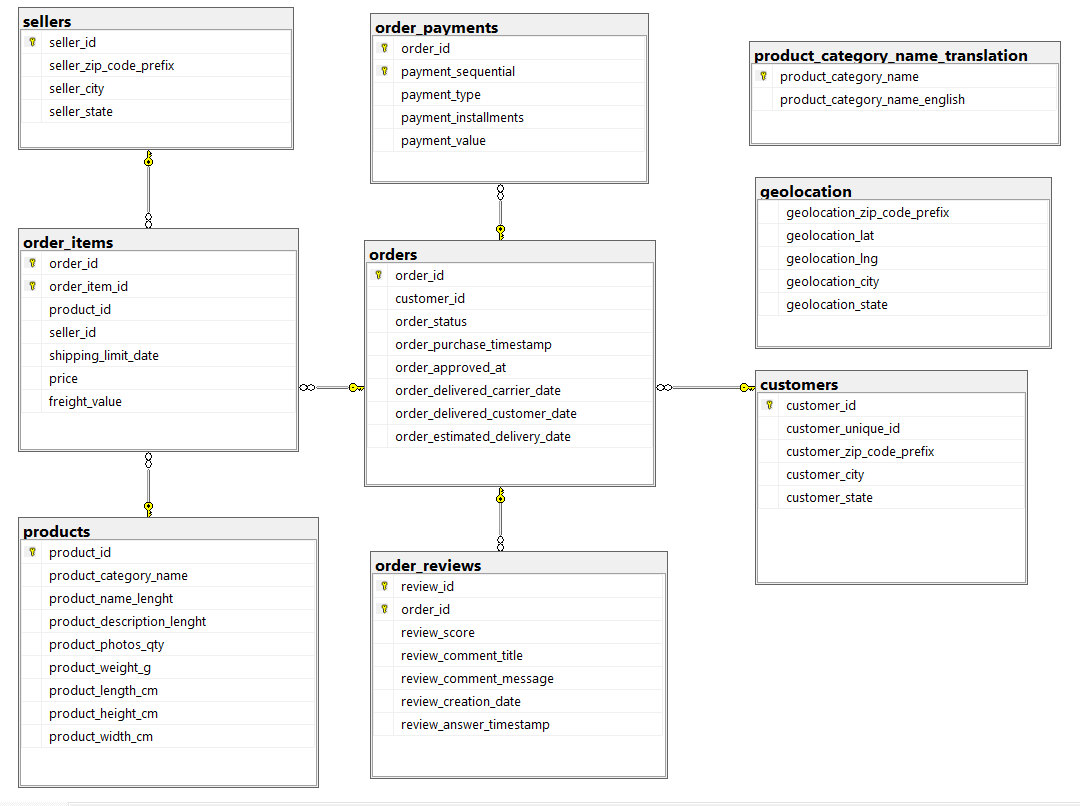

#### Data Overview

The Olist dataset is a relational e-commerce database that includes information about customers, orders, products, sellers, payments and customer reviews.

The tables are connected through primary and foreign keys, which makes it possible to analyse the full order process and check data consistency across the dataset.

The **orders** table is the main table in the database. It connects customers with order items, payments and reviews.

The main tables used in this project are:

- **customers** – customer information
- **orders** – order process and status data
- **order_items** – products included in each order
- **products** – product details and categories
- **order_payments** – payment information
- **order_reviews** – customer review data
- **sellers** – seller information

# Data Profiling

Before running the validation checks, the dataset was profiled to understand its basic structure and the quality of the main fields.

This step helps identify simple issues such as missing values, duplicate keys and unusual distributions in important columns.

#### Record count by table
This check shows the number of records in the main relational tables.

In [4]:
pd.read_sql("""
select 'customers' as table_name, count(*) as row_count from customers
union all
select 'orders', count(*) from orders
union all
select 'order_items', count(*) from order_items
union all
select 'order_payments', count(*) from order_payments
union all
select 'order_reviews', count(*) from order_reviews
union all
select 'products', count(*) from products
union all
select 'sellers', count(*) from sellers;
""", engine)

,table_name,row_count
0,customers,99441
1,orders,99441
2,order_items,112650
3,order_payments,103886
4,order_reviews,99224
5,products,32951
6,sellers,3095


#### Missing values in key fields (orders)
This check measures the completeness of the most important columns in the orders table.

In [5]:
pd.read_sql("""
select
    count(*) as total_rows,
    sum(case when order_id is null then 1 else 0 end) as null_order_id,
    sum(case when customer_id is null then 1 else 0 end) as null_customer_id,
    sum(case when order_status is null then 1 else 0 end) as null_order_status,
    sum(case when order_purchase_timestamp is null then 1 else 0 end) as null_purchase_timestamp,
    sum(case when order_delivered_customer_date is null then 1 else 0 end) as null_delivered_customer_date
from orders;
""", engine)

,total_rows,null_order_id,null_customer_id,null_order_status,null_purchase_timestamp,null_delivered_customer_date
0,99441,0,0,0,0,2965


#### Duplicate key check (orders)
This check verifies whether the main business key contains duplicate values.

In [6]:
pd.read_sql("""
select
    order_id,
    count(*) as duplicate_count
from orders
group by order_id
having count(*) > 1;
""", engine)

,order_id,duplicate_count


#### Distribution of order status
This check shows the distribution of values in the main order status field.

In [7]:
pd.read_sql("""
select
    order_status,
    count(*) as orders_count,
    round(100.0 * count(*) / sum(count(*)) over (), 2) as pct_of_total
from orders
group by order_status
order by orders_count desc;
""", engine)

,order_status,orders_count,pct_of_total
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


#### Summary:
The profiling step provided a basic overview of dataset size, completeness, key uniqueness and the distribution of order statuses.

# Data Quality Validation Framework

This section presents a rule-based data quality validation framework used to identify records that break key completeness, consistency and business logic rules in the dataset.

#### Validation summary table
The query below applies a set of main validation rules and returns the number of records that fail each rule.

In [27]:
pd.read_sql("""
with orders_without_items as (
    select count(*) as count
    from orders o
    left join order_items oi
        on o.order_id = oi.order_id
    where oi.order_id is null
),

orders_without_payments as (
    select count(*) as count
    from orders o
    left join order_payments op
        on o.order_id = op.order_id
    where op.order_id is null
),

delivered_without_delivery_date as (
    select count(*) as count
    from orders
    where order_status = 'delivered'
      and order_delivered_customer_date is null
),

non_positive_payments as (
    select count(*) as count
    from order_payments
    where payment_value <= 0
),

invalid_review_scores as (
    select count(*) as count
    from order_reviews
    where review_score < 1 or review_score > 5
),

products_without_category as (
    select count(*) as count
    from products
    where product_category_name is null
)

select 'orders_without_items' as rule_name, count from orders_without_items
union all
select 'orders_without_payments', count from orders_without_payments
union all
select 'delivered_without_delivery_date', count from delivered_without_delivery_date
union all
select 'non_positive_payments', count from non_positive_payments
union all
select 'invalid_review_scores', count from invalid_review_scores
union all
select 'products_without_category', count from products_without_category;
""", engine)

,rule_name,count
0,orders_without_items,775
1,orders_without_payments,1
2,delivered_without_delivery_date,8
3,non_positive_payments,9
4,invalid_review_scores,0
5,products_without_category,610


#### Summary:
The validation checks found records that break important business and completeness rules related to order items, payments, delivery dates, payment values, review scores and product categories.

# Key Findings

The validation framework found several data quality issues in both transactional and master data tables.

The most important issues were related to missing order-item links, missing payment records, missing delivery dates for delivered orders, and missing product category names.

These problems may reduce reporting quality, limit process visibility and affect further analysis.

# Root Cause Analysis

To better understand selected validation issues, additional checks were performed to see whether the problems were related to specific order statuses, time periods or data areas.

### Order without payment

In [18]:
pd.read_sql("""
select
o.order_id,
o.order_status,
count(*) as orders_without_payments
from orders o
left join order_payments op
on o.order_id = op.order_id
where op.order_id is null
group by o.order_status, o.order_id
order by orders_without_payments desc;
""", engine)

,order_id,order_status,orders_without_payments
0,bfbd0f9bdef84302105ad712db648a6c,delivered,1


In [19]:
pd.read_sql("""
select *
from orders
where order_id = 'bfbd0f9bdef84302105ad712db648a6c';
""", engine)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04


In [20]:
pd.read_sql("""
select *
from order_items
where order_id = 'bfbd0f9bdef84302105ad712db648a6c';
""", engine)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,bfbd0f9bdef84302105ad712db648a6c,1,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,2016-09-19 23:11:33,44.99,2.83
1,bfbd0f9bdef84302105ad712db648a6c,2,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,2016-09-19 23:11:33,44.99,2.83
2,bfbd0f9bdef84302105ad712db648a6c,3,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,2016-09-19 23:11:33,44.99,2.83


In [21]:
pd.read_sql("""
SELECT *
FROM order_reviews
WHERE order_id = 'bfbd0f9bdef84302105ad712db648a6c';
""", engine)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,6916ca4502d6d3bfd39818759d55d536,bfbd0f9bdef84302105ad712db648a6c,1,None,nao recebi o produto e nem resposta da empresa,2016-10-06,2016-10-07 18:32:28


In [22]:
pd.read_sql("""
SELECT *
FROM order_payments
WHERE order_id = 'bfbd0f9bdef84302105ad712db648a6c';
""", engine)

,order_id,payment_sequential,payment_type,payment_installments,payment_value


#### Interpretation

The root cause analysis showed that the only order without a payment record has the status `delivered`. A more detailed check confirmed that the order exists in the orders table and has related order items, but the payment record is missing.

This suggests a real transactional inconsistency rather than a normal business exception. From a business point of view, this type of issue may affect transaction completeness and reduce the reliability of reporting or reconciliation processes.

# Recommendations

Based on the profiling, validation checks and root cause analysis, several actions could help improve data quality in the dataset.

- investigate records with missing order-item and payment relationships,
- review the process logic for delivered orders without final delivery dates,
- apply validation rules for positive payment values and valid review score ranges,
- improve completeness checks for product category assignment,
- implement recurring SQL-based validation checks as part of the data loading and monitoring process.

# Conclusion

This project presented a SQL-based approach to data profiling, rule-based data quality validation and root cause analysis using a relational e-commerce dataset in SQL Server.

The analysis showed that structured SQL checks can help identify issues related to completeness, consistency and business rule compliance in transactional and master data tables. It also showed how validation results can support data quality monitoring, reporting and further investigation of unusual records.